<a href="https://colab.research.google.com/github/jdansb/Econophysics/blob/main/files/gas_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kinetic model with a marginalist approach

This is a different article that seeks to rely in part on marginalist theory as presented in the paper “[Microeconomics of the ideal gas like market models](https://arxiv.org/abs/0905.3972)”. Let us assume:

- Agent $i$ produces only $Q_{i}$ units of commodity $i$, and their money at time $t$ is given by $m_{i}(t)$.
  - Notice that, although this is a model that attempts to provide a microeconomic justification within marginalism, it assumes a condition of equality in the market among all agents as producers and consumers. Such equality does not exist, not only materially but also legally, since private ownership of the means of production assigns different roles to each agent in the production process.

- We want to understand how the money held by agent $m_{i}(t)$ varies over time $t$.
- Considering an exchange between two agents $i$ and $j$, we define a utility function given by $U_{i}(x_{i}, x_{j}, m_{i}) = x_{i}^{\alpha_{i}} x_{j}^{\alpha_{j}} m_{i}^{\alpha_{m}},$
where $x_{i}$ and $x_{j}$ denote the consumption of commodities $i$ and $j$ by the agent in question.
  -  A utility function measures the consumer’s preferences and satisfaction with different goods or services. It is important to stress that there is a certain arbitrariness in choosing such a specific functional form. The chosen function is called Cobb–Douglas and is popular in marginalist literature.

- For convenience, we denote $m_{i}(t+1)=m_{i}$ and $m_{i}(t)=M_{i}$.
- For simplicity, we also assume that $\alpha_{i}+\alpha_{j}+\alpha_{m}=1$.


Denoting the price of commodity $i$ by $p_{i}$, we then define a budget constraint for agent $i$ as:

$$ p_{i}x_{i}+p_{j}x_{j}+m_{i}\leq M_{i}+p_{i}Q_{i} $$

In other words, the amount that agent $i$ can spend by consuming quantities $x_{i}$ and $x_{j}$ of the two commodities, together with the money they retain after the exchange, cannot exceed the money they possessed in the previous time step plus the revenue obtained from selling the commodity they produce. Indeed, since $x_{i}$ represents consumption, then $p_{i}x_{i}+p_{j}x_{j}=\Delta m_{i}$ corresponds to the monetary flow spent on consumption. Likewise, if we denote $p_{i}Q_{i}=\Delta M_{i}$ as the monetary flow earned from production, we can rewrite the budget constraint as

\[
\Delta m_{i}+m_{i}\leq M_{i}+\Delta M_{i}.
\]

In fact, for a conservative system we necessarily have

\[
\Delta m_{i}+m_{i}=M_{i}+\Delta M_{i}.
\]

The idea is that agents seek to maximize their utility functions. Therefore, the optimization problem consists of maximizing the utility function subject to the budget constraint:

\[
\begin{aligned}
U_{i}(x_{i},x_{j},m_{i}) &= x_{i}^{\alpha_{i}}x_{j}^{\alpha_{j}}m_{i}^{\alpha_{m}},\\
p_{i}x_{i}+p_{j}x_{j}+m_{i}-M_{i}-p_{i}Q_{i} &= 0.
\end{aligned}
\]

In [ ]:
import numpy as np
N=1000 #quantidade de agentes
passos = 10000 #passos de monte carlo
tm = 9000 #A partir de qual passo coletar dados
m = np.array(N*[1.0]) #Dinheiro dos agentes
l= np.random.uniform(0, 1, size=N)

eta = [[] for _ in range(N)]
res=[]  #Os dinheiros de cada agente a cada ano
med=m.copy()  #A riqueza média do agente
ag=[]         #A riqueza um único agente
id=0          #Agente escolhido
c=1           #contador
for t in range(passos):
  # Geramos os lambda e alphas
  a = np.random.uniform(0, 1, size=N)
  a = a / np.sum(a)
  #Copiamos o dinheiro atual
  m0=m.copy()

  #Geramos a fração da riqeuza monetária circulante
  MV=0
  for j in range(N):
      MV+=(1-l[j])*m0[j]

  #Atualizamos o dinheiro atual de cada agente
  for i in range(N):
    m[i]=l[i]*m0[i]+a[i]*MV                      #Artigo 1
    if(t>=tm):
      eta[i].append(MV*a[i])
    #m[i]=l[i]*m0[i]+np.random.normal(0, 0.01)   #Artigo
    #m[i]=l[i]*m0[i]+np.random.exponential(scale=1.0)


  #Então guardamos os dados
  if(t>=tm):
    res.extend(m)
#
    med+=m
    c+=1
    ag.append(m[id])

med=med/c

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
janela=int(np.sqrt(len(eta[0])))
# teste de Ljung-Box
c=0;d=0
for e in eta:
  teste = acorr_ljungbox(e, lags=[janela], return_df=True)

  if (teste["lb_pvalue"].iloc[0]>0.05):
    c+=1
    #print("Não há autocorrelação")
  else:
    d+=1
    #print("Há autocorrelação")


medias = []
desvios =[]

for i in range(0, len(eta[0]), janela):

    trecho = eta[10][i:i+janela]

    medias.append(np.mean(trecho))
    desvios.append(np.std(trecho))
print("Razão entre desvio padrão e média da média:",np.std(medias)/np.mean(medias))
print("Razão entre desvio padrão e média do desvio:",np.std(desvios)/np.mean(desvios))

Razão entre desvio padrão e média da média: 0.10060010177488371
Razão entre desvio padrão e média do desvio: 0.08571710106641703


(0.01, 1.1)

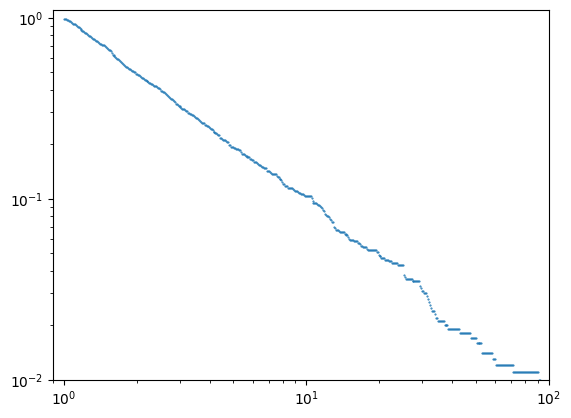

In [ ]:
# @title
import matplotlib.pyplot as plt
a= np.array(med)  # Transformamos a lista em um array
ccfd = []  # Guardaremos as probabilidades
# Vamos definir que valores vamos pegar.
x = np.logspace(0, 4, 1000)
for i in x:  # Vamos percorrer todos os valores possíveis
    # Quantos agentes tem menos ou igual a i de moedas
    index = np.count_nonzero(a <= i)
    prob = 1-index/(len(a))  # A probabilidade de alguém ter mais que i
    ccfd.append(prob)  # Salvamos

b = -(np.array(ccfd) == 0).sum() #Plotamos até  ter zero probabilidade
plt.plot(x[:b], ccfd[:b],'o', markersize=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlim(9E-1,1E2)
plt.ylim(1E-2,1.1E0)



(0.01, 1.0)

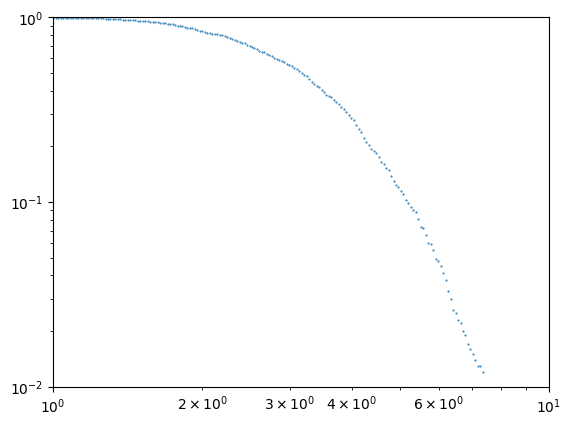

In [ ]:
import matplotlib.pyplot as plt
a= np.array(ag)  # Transformamos a lista em um array
ccfd = []  # Guardaremos as probabilidades
# Vamos definir que valores vamos pegar.
x = np.logspace(-1, 4, 1000)
for i in x:  # Vamos percorrer todos os valores possíveis
    # Quantos agentes tem menos ou igual a i de moedas
    index = np.count_nonzero(a <= i)
    prob = 1-index/(len(ag))  # A probabilidade de alguém ter mais que i
    ccfd.append(prob)  # Salvamos

b = -(np.array(ccfd) == 0).sum() #Plotamos até  ter zero probabilidade
plt.plot(x[:b], ccfd[:b],'o', markersize=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlim(1E-0,1E1)
plt.ylim(1E-2,1E0)


(0.01, 1.0)

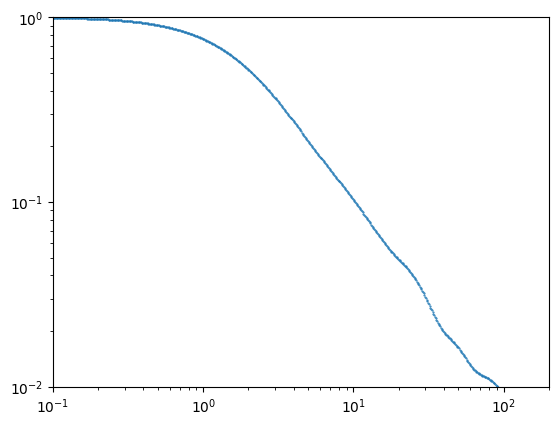

In [ ]:
# @title
import matplotlib.pyplot as plt
a= np.array(res)  # Transformamos a lista em um array
ccfd = []  # Guardaremos as probabilidades
# Vamos definir que valores vamos pegar.
x = np.logspace(-1, 4, 1000)
for i in x:  # Vamos percorrer todos os valores possíveis
    # Quantos agentes tem menos ou igual a i de moedas
    index = np.count_nonzero(a <= i)
    prob = 1-index/(len(a))  # A probabilidade de alguém ter mais que i
    ccfd.append(prob)  # Salvamos

b = -(np.array(ccfd) == 0).sum() #Plotamos até  ter zero probabilidade
plt.plot(x[:b], ccfd[:b],'o', markersize=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlim(1E-1,2E2)
plt.ylim(1E-2,1E0)

